# **원의 방정식**

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# 1. 원의 설정: 중심 (h, k)와 반지름 r
h, k = 2, 3
r = 5

# 2. 원을 그리기 위한 데이터 생성 (0부터 2pi까지 100개의 점)
theta = np.linspace(0, 2 * np.pi, 100)
x = h + r * np.cos(theta)  # cos 사용
y = k + r * np.sin(theta)  # sin 사용

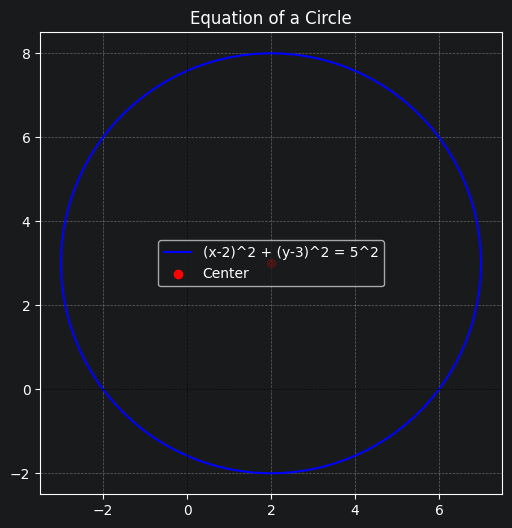

In [4]:
# 3. 시각화
plt.figure(figsize=(6,6))
plt.plot(x, y, label=f'(x-{h})^2 + (y-{k})^2 = {r}^2', color='blue')
plt.scatter(h, k, color='red', label='Center') # 중심점

plt.axhline(0, color='black', lw=0.5)
plt.axvline(0, color='black', lw=0.5)
plt.gca().set_aspect('equal') # 원이 찌그러지지 않게!
plt.grid(True, linestyle='--')
plt.legend()
plt.title("Equation of a Circle")
plt.show()

## **두 점에서 만날 때, d < r**

In [5]:
def get_dist_pt_line(p, a, b, c):
    x1, y1 = p
    return np.abs(a*x1 + b*y1 + c) / np.sqrt(a**2 + b**2)

# 1. 설정: 원의 중심(h, k), 반지름(r) / 직선 ax + by + c = 0
h, k, r = 0, 0, 5        # 원: x^2 + y^2 = 25
a, b, c = 3, -4, 10      # 직선: 3x - 4y + 10 = 0

center = np.array([h, k])

# 2. 판별 로직
d = get_dist_pt_line(center, a, b, c)

if d < r:
    result_text = "Two Points (Intersects)"
elif d == r:
    result_text = "One Point (Tangents)"
else:
    result_text = "No Points (Does not meet)"

print(f"Distance (d): {d}, Radius (r): {r}")
print(f"Result: {result_text}")

# 3. 시각화 데이터
theta = np.linspace(0, 2*np.pi, 100)
circle_x = h + r * np.cos(theta)
circle_y = k + r * np.sin(theta)

x_vals = np.linspace(-10, 10, 100)
line_y = (-a * x_vals - c) / b

Distance (d): 2.0, Radius (r): 5
Result: Two Points (Intersects)


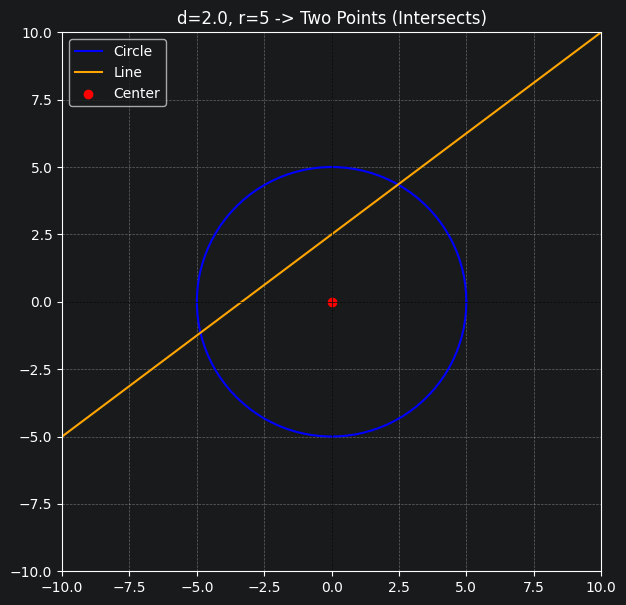

In [6]:
plt.figure(figsize=(7, 7))
plt.plot(circle_x, circle_y, label='Circle', color='blue') # 원
plt.plot(x_vals, line_y, label='Line', color='orange')    # 직선
plt.scatter(h, k, color='red', label='Center')           # 중심

plt.title(f"d={d}, r={r} -> {result_text}")
plt.axhline(0, color='black', lw=0.5)
plt.axvline(0, color='black', lw=0.5)
plt.xlim(-10, 10)
plt.ylim(-10, 10)
plt.gca().set_aspect('equal')
plt.grid(True, linestyle='--')
plt.legend()
plt.show()

## **접할 때, d = r**

In [7]:
# 1. 원 설정: 중심(0,0), 반지름 5
h, k, r = 0, 0, 5

# 2. 직선 설정: 3x - 4y + 25 = 0 (d=r이 되도록 세팅)
a, b, c = 3, -4, 25

# 3. 거리 계산 (검증용)
d = np.abs(a*h + b*k + c) / np.sqrt(a**2 + b**2)
print(f"Distance d: {d}, Radius r: {r}")
print(f"Is tangent? {np.isclose(d, r)}") # 소수점 오차 고려해서 비교

# 4. 시각화 데이터
theta = np.linspace(0, 2*np.pi, 100)
cx, cy = h + r*np.cos(theta), k + r*np.sin(theta)

x_range = np.linspace(-10, 10, 100)
ly = (-a * x_range - c) / b

Distance d: 5.0, Radius r: 5
Is tangent? True


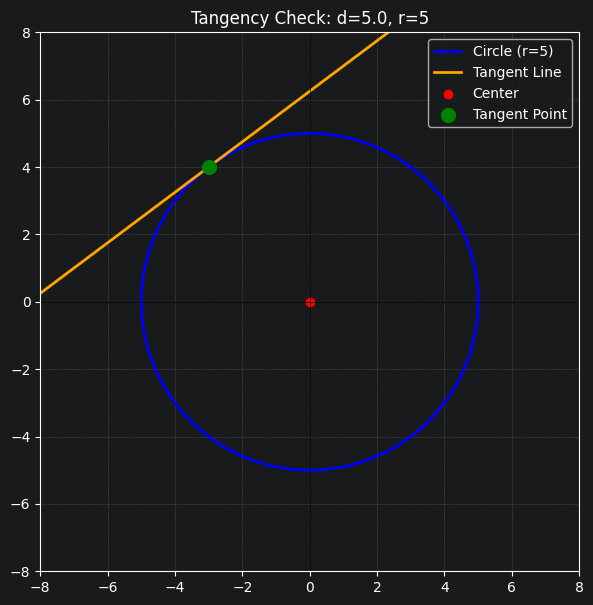

In [8]:
plt.figure(figsize=(7,7))
plt.plot(cx, cy, label='Circle (r=5)', color='blue', lw=2)
plt.plot(x_range, ly, label='Tangent Line', color='orange', lw=2)
plt.scatter(h, k, color='red', label='Center')

# Tangent Point 표시 (수학적 계산 결과)
# 접점 공식: (-ac/(a^2+b^2), -bc/(a^2+b^2)) -> 중심이 (0,0)일 때
tp_x = -a*c / (a**2 + b**2)
tp_y = -b*c / (a**2 + b**2)
plt.scatter(tp_x, tp_y, color='green', s=100, zorder=5, label='Tangent Point')

plt.title(f"Tangency Check: d={d}, r={r}")
plt.axhline(0, color='black', lw=0.5)
plt.axvline(0, color='black', lw=0.5)
plt.xlim(-8, 8)
plt.ylim(-8, 8)
plt.gca().set_aspect('equal')
plt.grid(True, linestyle=':')
plt.legend()
plt.show()

## **만나지 않을 떄 , d > r**

In [9]:
# 1. 원 설정: 중심(0,0), 반지름 3
h, k, r = 0, 0, 3

# 2. 직선 설정: 3x - 4y + 25 = 0
# (중심에서 거리가 5이므로, 반지름 3보다 큽니다)
a, b, c = 3, -4, 25

# 3. 거리 계산 (d)
d = np.abs(a*h + b*k + c) / np.sqrt(a**2 + b**2)
print(f"Distance d: {d}, Radius r: {r}")
print(f"Meets? {d <= r}") # 만나면 True, 안 만나면 False

# 4. 데이터 생성
theta = np.linspace(0, 2*np.pi, 100)
cx, cy = h + r*np.sin(theta), k + r*np.cos(theta)

x_range = np.linspace(-10, 10, 100)
ly = (-a * x_range - c) / b


Distance d: 5.0, Radius r: 3
Meets? False


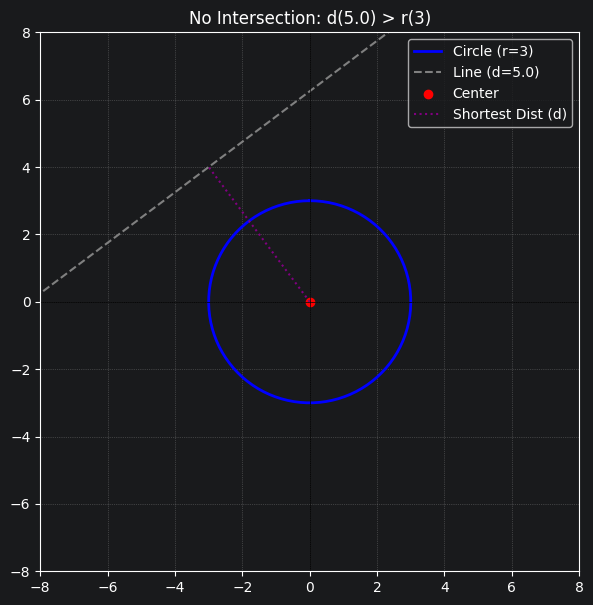

In [10]:
plt.figure(figsize=(7,7))
plt.plot(cx, cy, label=f'Circle (r={r})', color='blue', lw=2)
plt.plot(x_range, ly, label=f'Line (d={d})', color='gray', linestyle='--')
plt.scatter(h, k, color='red', label='Center')

# 최단거리 선 표시 (중심에서 직선으로 수선 내리기)
# 접점 공식과 같은 원리로 수선의 발을 찾음
foot_x = -a*c / (a**2 + b**2)
foot_y = -b*c / (a**2 + b**2)
plt.plot([h, foot_x], [k, foot_y], color='purple', label='Shortest Dist (d)', linestyle=':')

plt.title(f"No Intersection: d({d}) > r({r})")
plt.axhline(0, color='black', lw=0.5)
plt.axvline(0, color='black', lw=0.5)
plt.xlim(-8, 8)
plt.ylim(-8, 8)
plt.gca().set_aspect('equal')
plt.grid(True, linestyle=':')
plt.legend()
plt.show()